<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_echo = 1/128  # Hypothetical echo–echo coupling


In [2]:
def generate_echo_pair(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    echo_A = np.sin(X) * np.sin(Y)
    echo_B = np.sin(X + np.pi/2) * np.sin(Y + np.pi/2)
    return echo_A, echo_B


In [3]:
def echo_resonance(echo_A, echo_B, beta=1/128):
    grad_A_x, grad_A_y = np.gradient(echo_A)
    grad_B_x, grad_B_y = np.gradient(echo_B)

    theta_A = np.arctan2(grad_A_y, grad_A_x)
    theta_B = np.arctan2(grad_B_y, grad_B_x)
    phase_diff = theta_A - theta_B

    resonance = -beta * np.sin(phase_diff)
    echo_A += resonance
    echo_B -= resonance
    return echo_A, echo_B


In [4]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [5]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]

def residual_energy(field_A, field_B):
    return np.mean((field_A + field_B)**2)


Echo A fidelity: 0.9414
Echo B fidelity: 0.9417
Residual resonance energy: 0.076044


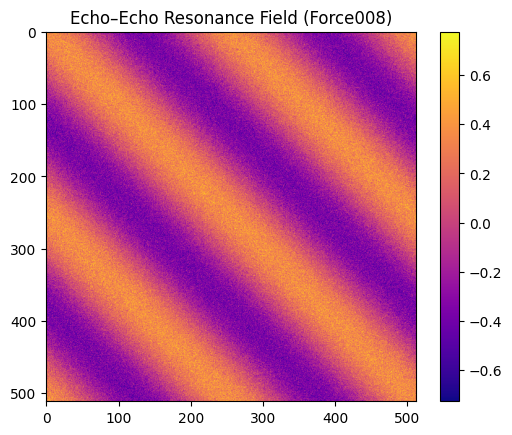

In [6]:
echo_A, echo_B = generate_echo_pair(grid_size)
echo_A_c, echo_B_c = echo_resonance(echo_A, echo_B, beta_echo)

echo_A_e = evolve_field(echo_A_c, e_folds)
echo_B_e = evolve_field(echo_B_c, e_folds)

f_A = memory_fidelity(echo_A_c, echo_A_e)
f_B = memory_fidelity(echo_B_c, echo_B_e)
residual = residual_energy(echo_A_e, echo_B_e)

print(f"Echo A fidelity: {f_A:.4f}")
print(f"Echo B fidelity: {f_B:.4f}")
print(f"Residual resonance energy: {residual:.6f}")

plt.imshow(echo_A_e + echo_B_e, cmap='plasma')
plt.title("Echo–Echo Resonance Field (Force008)")
plt.colorbar()
plt.show()
